## Agent class:

In [1]:

import numpy as np
import pandas as pd

class Agent:
    def __init__(self, current_location, b, reciprocity, partner_location):
        self.current_location = current_location  # initial location
        self.b = b  # egocentric bias parameter
        self.last_partner_location = partner_location 
        self.last_my_location = current_location
        self.reciprocity = reciprocity
        self.last_to_last_location = current_location
        self.current_partner_location = partner_location
        self.score = 0 
        self.score_solo = 0
        self.split = 0.5
        
        
    def move(self):
        # Add noise to current location with controlled variance
        ##add +/- 1 to the current location
        # self.current_location = self.current_location + np.random.choice([-1, 0, 1])
        self.current_location = self.current_location
        # + np.random.normal (0,0.2)
        # Ensure location stays in grid
        self.current_location = max(1, min(9, self.current_location))
        ##round it to the nearest integer
        # self.current_location = round(self.current_location)


    
        
    def belief_update(self, partner_location, prev_partner_location, outcome, 
                      update_function
                      
                      ):
        # Calculate difference between agent positions
        ##use the following functions to update based on bias, outcome and asymmetry

        ##did partner move towards you or away from you?
        # partner_compromise = partner_location - prev_partner_location
        delta_d =  ( (self.current_location - self.current_partner_location ) / 8) #8


        update =update_function(self, self.current_partner_location, self.b, outcome,
                                reward=self.score, delta_d=delta_d)
       
        self.current_location += update
        ##if current location is close to 9, reduce the update, scale it

        # Ensure location stays in grid
        self.current_location = max(1, min(9, self.current_location))
        
    
    def update_winStayLoseShift(self, partner_location, bias, outcome, 
                            reward,
                            alpha=1.0, 
                          ):
        
        if outcome == 'reward':
            update = np.random.choice([1, 0], p=[0.1, 0.9])
        else:  # outcome == 'loss'
            update = np.random.choice([-1, 0], p=[0.9, 0.1]) 
        
        
        return update
    
    def update_outcome(self, partner_location, bias, outcome,
                            reward,delta_d = 1.0, alpha=1.0):
        if outcome == 'reward':
            # p_fwd = 0.9
            p_fwd = max(0.1, 1 - (self.current_location / 9))
            # print(f"p_fwd: {p_fwd} current_location: {self.current_location}")
            update = np.random.choice([0, 1], p=[1 - p_fwd, p_fwd])
        else:  # loss
            p_back = 0.9
            update = np.random.choice([0, -1], p=[1 - p_back, p_back])

        # self.split =  0.5 + (delta_d/9) + (update/9)  # Scale split based on update
        return alpha * update
    

    def update_egocentric2(self, partner_location, bias, outcome, 
                     reward, delta_d, alpha=1):
        # Calculate effective bias - higher when delta_d is large, negligible when small
        abs_delta = abs(delta_d)

        # Minimum threshold for bias effects
        min_delta_for_bias = 8/8 #2/8

        if outcome == 'reward':
            if delta_d > 0:  # Agent ahead
                # Combine edge effects with bias effects
                # p_fwd = max(0.1, 1 - (self.current_location / 9))
                # p_fwd = max(0.1, np.exp(-self.current_location / 3))
                p_fwd = 0.1
                update = np.random.choice([0, delta_d], p=[1 - p_fwd, p_fwd])
                self.split =  0.5 + delta_d + update  # Scale split based on update

                
            else:  # Agent behind

                update = np.random.choice([0, -delta_d], p=[bias, 1 - bias])
                reverse_update = np.random.choice([0, -delta_d], p=[1- bias, bias]) 
                self.split =  0.5 - abs(delta_d) + abs(reverse_update)  # Scale split based on update

        else:  # outcome == 'loss'
            if delta_d > 0:  # Agent ahead

                update = np.random.choice([0, -delta_d], p=[bias, 1 - bias])
                reverse_update = np.random.choice([0, -delta_d], p=[1- bias, bias])
                self.split = 0.5 + abs(delta_d) - abs(reverse_update)  # Scale split based on update

            else:  # Agent behind
                ##p_bwd should be low when current location is low
                
                # p_bwd = max(0.1, (self.current_location/9))
                p_bwd = 0.9
                update = np.random.choice([0, delta_d], p=[1 - p_bwd, p_bwd])
                self.split = 0.5 + delta_d + update

    # Update split calculation
    # self.split = 0.5 + delta_d + update
        self.split = max(0.2, min(0.8, self.split))
        # print(f"split: {self.split} current_location: {self.current_location} partner_location: {partner_location} delta_d: {delta_d} update: {update}")
        
        return alpha * update

    

    
            

    def update_outcome_bothlowbias(self, partner_location, bias, outcome,
                                    reward, delta_d,
                                    alpha=1.0):
            bias = 0.1
            update = self.update_egocentric2(partner_location, bias, outcome,
                                    reward, delta_d)
            return update
            
    def update_outcome_bothhighbias(self, partner_location, bias, outcome,
                                    reward, delta_d,
                                    alpha=1.0):
            bias = 0.9
            update = self.update_egocentric2(partner_location, bias, outcome,
                                    reward, delta_d)
            
            return update
        

           
    



## Grid

In [ ]:
class Grid:
    def __init__(self, agent1, agent2, predType):
        self.agent1 = agent1
        self.agent2 = agent2
        self.outcome_location = 0
        self.steps = 9
        self.ptype = predType  #  1 or 0 

    def get_attack_prob(self, x, max_attack_prob):
        """
        get the predator's attack probability given the location that the players choose
        """
        if x>2:
            return (x/20)**2*max_attack_prob
        else:
            return 0
        #return max(0, max_attack_prob - (steps - x)*0.1)
    
    def get_predator_choice(self, x, ptype):
        """
        determine if predator attack given the location that the players choose
        """
        if ptype==1:
            prob = self.get_attack_prob(x, max_attack_prob=4.8)
            # print(prob, x)
        elif ptype==0:
            prob = self.get_attack_prob(x, max_attack_prob=2.6)
        c = np.random.choice([0, 1], 1, p=[1-prob, prob])
        return c

    def get_potential_reward(self, x):
        return x ** 2
    
        
    def play_solo_round(self):
        self.agent1.move()
        self.agent2.move()
        agent1_r = self.get_potential_reward(round(self.agent1.current_location))
        agent2_r = self.get_potential_reward(round(self.agent2.current_location))
        agent1_attck = self.get_predator_choice(round(self.agent1.current_location), self.ptype)
        agent2_attck = self.get_predator_choice(round(self.agent2.current_location), self.ptype)
        # print(agent1_attck, agent2_attck)
        if agent1_attck[0] == 1:
            self.agent1.score -= 20
        elif agent1_attck[0] == 0:
            self.agent1.score += agent1_r

        if agent2_attck[0] == 1:
            self.agent2.score -= 20
        elif agent2_attck[0] == 0:
            self.agent2.score += agent2_r
    

    def play_round(self, update_func):
        self.agent1.last_to_last_location = self.agent1.last_my_location
        self.agent2.last_to_last_location = self.agent2.last_my_location

        self.agent1.last_my_location = self.agent1.current_location
        self.agent2.last_my_location = self.agent2.current_location

        self.agent1.last_partner_location = self.agent2.current_location
        self.agent2.last_partner_location = self.agent1.current_location

        self.agent1.move()
        self.agent2.move()
        self.outcome_location = (self.agent1.current_location + self.agent2.current_location) / 2

        reward = self.get_potential_reward(round(self.outcome_location))
        # attack_prob = self.get_attack_prob(self.outcome_location)
        attack_choice = self.get_predator_choice(round(self.outcome_location), self.ptype)

        self.agent1.current_partner_location = self.agent2.current_location
        self.agent2.current_partner_location = self.agent1.current_location

        if attack_choice[0] == 1:
            self.agent1.score -= 10
            self.agent2.score -= 10 
            return 'attack'
        else:
            self.agent1.score += reward / 2 
            self.agent2.score += reward / 2
            # self.score += reward
            return 'reward'



## run model

In [3]:
##tqdm 
from tqdm import tqdm

In [4]:
# Simulation parameters
results = []
# bias_values = [0.1, 0.5, 0.9]  # Low, medium, high egocentric bias
# bias_values = [0.1,0.9]
bias_values = [0.0]
update_functions = [
    # Agent.update_outcome_egocentric,
    # Agent.update_outcome_only,
    # Agent.update_outcome,
    Agent.update_outcome_bothhighbias,
    Agent.update_outcome_bothlowbias,
    # Agent.update_outcome_rahighbias,
    # Agent.update_outcome_ralowbias,

   

]

agent_locs = [1, 2, 3, 4, 5, 6, 7, 8, 9]

num_runs = 200 #200
# Simulation loop
# for n in range(num_runs):
for n in tqdm(range(num_runs), desc="Running simulations"):
    for bias_i in bias_values:
        for ptype in [0, 1]:  # Predator type
    # for bias_j in bias_values:
            for update_func in update_functions:
                for i in agent_locs:  # Agent 1's preferred location
                    for j in agent_locs:  # Agent 2's preferred location
                        agent1 = Agent(current_location=i, b=bias_i, reciprocity=0.5, partner_location=j)
                        agent2 = Agent(current_location=j, b=bias_i, reciprocity=0.5, partner_location=i)
                        grid = Grid(agent1, agent2, predType=ptype)  
                        for r in range(30):
                            grid.play_solo_round()
                        
                        agent1.score_solo = agent1.score
                        agent2.score_solo = agent2.score
                        agent1.score = 0
                        agent2.score = 0

                        for r in range(30):
                            # print(r)
                            outcome = grid.play_round(update_func)

                            agent1.belief_update(agent2.current_location, agent1.last_partner_location, outcome, update_func)
                            agent2.belief_update(agent1.current_location, agent2.last_partner_location, outcome, update_func)
                            
                            results.append([
                                n, r, i, j, bias_i, update_func.__name__,  
                                agent1.current_location, agent2.current_location, 
                                grid.outcome_location, outcome, agent1.score,
                                agent2.score, agent1.score+agent2.score ,
                                agent1.score_solo, agent2.score_solo,
                                ptype, agent1.split, agent2.split
                            ])

# Create DataFrame
df = pd.DataFrame(results, columns=[
    "n", 'trial', 'agent1_og', 'agent2_og', 'bias',
    "update_function",
    'agent1_location', 'agent2_location', 'outcome_location', 
    'outcome', 'agent1_score', 'agent2_score', 'score',
    'agent1_score_solo', 'agent2_score_solo',
    'predator_type', 'agent1_split', 'agent2_split'

    # 'agent1_delta_d', 'agent2_delta_d', 'agent1_update', 'agent2_update',
    # 'agent1_compromise', 'agent2_compromise', 
])


## Save DataFrame to CSV
# df.to_csv('simulation_results_27may.csv', index=False)

Running simulations: 100%|██████████| 200/200 [03:38<00:00,  1.09s/it]


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
##change in trial by trial (shift by 1 )

df['agent1_delta'] = df['agent1_location'] - df['agent1_location'].shift(1)
df['agent2_delta'] = df['agent2_location'] - df['agent2_location'].shift(1)
df['delta'] = df['agent1_location'].shift(1) - df['agent2_location'].shift(1)

##round delta
df['delta'] = df['delta'].round()

last_round = df[df['trial'] == 29].copy()

last_round['agent1_change'] = last_round['agent1_location'] - last_round['agent1_og']
last_round['agent2_change'] = last_round['agent2_location'] - last_round['agent2_og']
last_round['delta_og'] = last_round['agent1_og'] - last_round['agent2_og']








In [9]:
## get change in score 
last_round['score_change_agent1'] = last_round['score'] - last_round['agent1_score_solo']
last_round['score_change_agent2'] = last_round['score'] - last_round['agent2_score_solo']

##drop where agent1_og or agent2_og is 5
last_round = last_round[(last_round['agent1_og'] != 5) & (last_round['agent2_og'] != 5)]
##add column for risk_diff: both risky, both less risky, one risky, one less risky
last_round['risk_category'] = np.where(
    (last_round['agent1_og'] > 5) & (last_round['agent2_og'] > 5), 'both_risky',
    np.where(
        (last_round['agent1_og'] < 5) & (last_round['agent2_og'] < 5), 'both_less_risky',
        np.where(
            (last_round['agent1_og'] > 5) & (last_round['agent2_og'] < 5), 'one_risky',
            'one_less_risky'
        )
    )
)


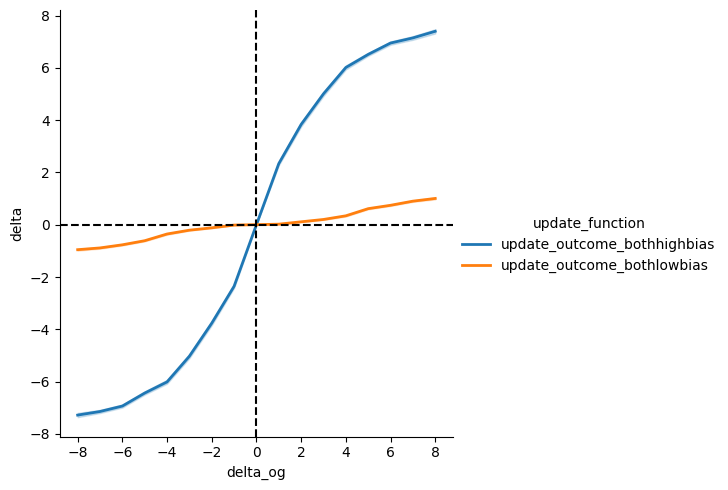

In [22]:
sns.relplot(x = 'delta_og',
            y ='delta', 
            hue='update_function',
            kind='line',
     data=last_round,
            
            linewidth=2,
            
            )

##line at 0
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')


In [16]:
##rename risk_category
last_round['risk_category'] = last_round['risk_category'].replace({
    'both_risky': 'Both RP',
    'both_less_risky': 'Both RA',
    'one_risky': 'self RP',
    'one_less_risky': 'self RA'
})

In [17]:
##if type contains 'low', then bias = 0.1
last_round['bias'] = last_round['update_function'].apply(lambda x: "0.1" if 'low' in x else "0.9")

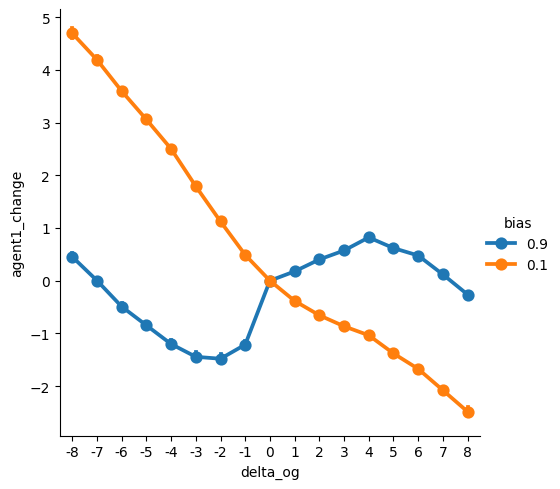

In [904]:
sns.catplot(data=last_round,
           x='delta_og', 
           kind='point',
           y = 'agent1_change',
           hue='bias',
           )

Text(0.5, 1.0, 'Change in Location by Dyad Type and Bias')

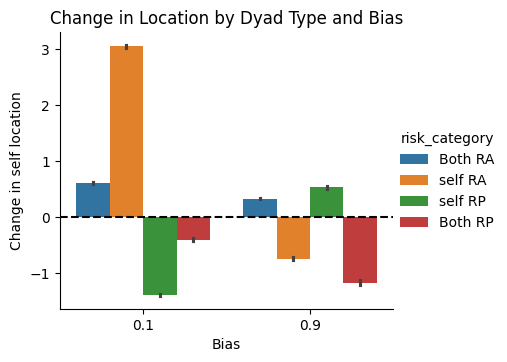

In [39]:
sns.catplot(data=last_round,
            hue='risk_category', y='agent1_change',
            x='bias',
            kind='bar', dodge=True, height=3.5,
            aspect=1.2,
           order=[0.1, 0.9]
            )


        ##rename x ticks
# labels = ['both risky', 'self RA, partner RP', 'both RA', 'partner RA']
# ##change x ticks using set_xticklabels
# ax.set_xticklabels(labels, rotation=0, fontsize=8)
plt.xlabel('Bias', fontsize=10)

plt.axhline(0, color='black', linestyle='--')
# plt.xticks(['RP+RP', 'RA+RP', 'RA+RA', 'RP+RA'], rotation=0, fontsize=8)

plt.ylabel('Change in self location', fontsize=10)

##plt title
plt.title('Change in Location by Dyad Type and Bias', fontsize=12)

In [18]:
##metl to put agent1_change and agent2_change in one column
melted = last_round.melt(id_vars=['risk_category', 'bias', 
                                  'agent1_og', 'agent2_og', 'delta_og',],
                         value_vars=['agent1_change', 'agent2_change'],
                         var_name='agent',
                         value_name='change')

In [19]:
melted.head()

,risk_category,bias,agent1_og,agent2_og,delta_og,agent,change
0,Both RA,0.9,1,1,0,agent1_change,0.000000
1,Both RA,0.9,1,2,-1,agent1_change,0.263672
2,Both RA,0.9,1,3,-2,agent1_change,0.616972
3,Both RA,0.9,1,4,-3,agent1_change,0.000000
4,self RA,0.9,1,6,-5,agent1_change,1.667004


In [20]:
##new columns with np.sign for change
melted['change_sign'] = melted['change'].apply(lambda x: 1 if x > 0 else -1 if x < 0 else 0)

In [21]:
##combine agent and risk_category into a new column
melted['agent_risk'] = melted['agent'] + '_' + melted['risk_category']




In [44]:
melted.head()

,risk_category,bias,agent1_og,agent2_og,delta_og,agent,change,change_sign,agent_risk
0,Both RA,0.9,1,1,0,Self,0.000000,0,agent1_change_Both RA
1,Both RA,0.9,1,2,-1,Self,0.263672,1,agent1_change_Both RA
2,Both RA,0.9,1,3,-2,Self,0.616972,1,agent1_change_Both RA
3,Both RA,0.9,1,4,-3,Self,0.000000,0,agent1_change_Both RA
4,self RA,0.9,1,6,-5,Self,1.667004,1,agent1_change_self RA


## actual plot

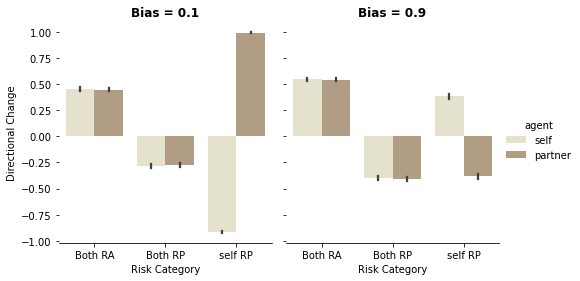

In [ ]:
palette = {
    "self": "#e8e4c9",
    "partner": "#b89c7d",
}
melted['agent'] = melted['agent'].replace({
    'agent1_change': 'self',
    'agent2_change': 'partner'
})

g = sns.catplot(
    data=melted,
    x='risk_category',
    y='change_sign',
    hue='agent',
    col='bias',
    kind='bar',
    dodge=True,
    palette=palette,
    height=4,
    aspect=0.9,
    order=['Both RA', 'Both RP', 'self RP'],
    col_order=['0.1', '0.9'],
    sharey=True,
)

g.set_axis_labels("Risk Category", "Directional Change")
g.set_titles(col_template="Bias = {col_name}", size=12, weight='bold')
g.despine(left=True)

# Remove default legend and add global one
# g._legend.remove()
# g.legend(bbox_to_anchor=(1, 1.05), loc='upper left')
# # g.fig.legend(
# #     ['Self', 'Partner'],
# #     loc='upper center',
# #     ncol=2,
# #     frameon=False,
# #     bbox_to_anchor=(0.5, 1.08),
# # )

# for ax in g.axes.flat:
#     ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
#     ax.tick_params(axis='x', labelrotation=20, labelsize=9)
#     ax.tick_params(axis='y', labelsize=9)

# g.fig.tight_layout()
g.fig.savefig('abm_bias.png', dpi=500, bbox_inches='tight')
# g.fig.savefig('abm_bias.pdf', bbox_inches='tight')
# plt.show()


## optimal location plots 

<Axes: xlabel='location', ylabel='total_reward'>

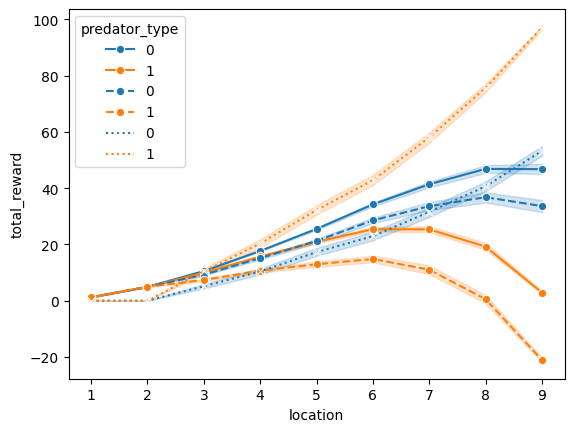

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def get_attack_prob(x, max_attack_prob):
    """
    get the predator's attack probability given the location that the players choose
    """
    if x>2:
        return (x/20)**2*max_attack_prob
    else:
        return 0
    #return max(0, max_attack_prob - (steps - x)*0.1)

def get_predator_choice(x, ptype):
    """
    determine if predator attack given the location that the players choose
    """
    if ptype==1:
        prob = get_attack_prob(x, max_attack_prob=4.8)
        # print(prob, x)
    elif ptype==0:
        prob = get_attack_prob(x, max_attack_prob=2.6)
    c = np.random.choice([0, 1], 1, p=[1-prob, prob])
    return c

def get_potential_reward(x):
    return x ** 2

##get total reward, total attacks after 60 trials for each x (1-9) and ptype (0,1)

def get_total_outcome( x, ptype):
    total_reward = 0
    total_attacks = 0
    net_reward = 0
    # for i in range(60):
    attack = get_predator_choice(x, ptype)
    if attack==1:
        total_attacks += 1
        net_reward -= 20
    else:
        reward = get_potential_reward(x)
        total_reward += reward
        net_reward += reward
    return total_reward, net_reward, total_attacks


outcome_list = []
for t in range(3000):
    for ptype in [0, 1]:
        for x in range(1, 10):
            total_reward, net_reward, total_attacks = get_total_outcome(x, ptype)
            outcome_list.append([ptype, x, total_reward, net_reward, total_attacks])





Text(0, 0.5, 'Total Reward and  Total Attacks (dashed) (scaled)')

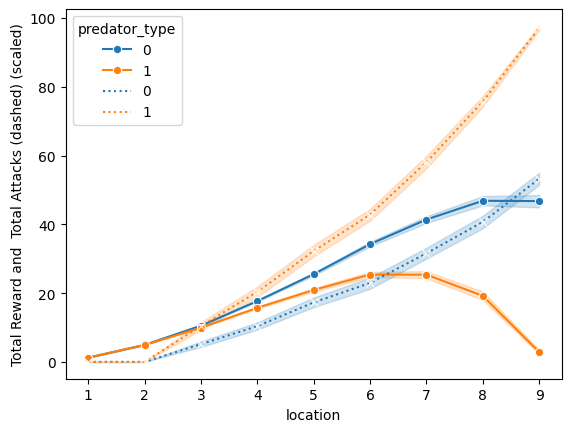

In [31]:
##plot
outcome_df = pd.DataFrame(outcome_list, columns=['predator_type', 'location', 'total_reward', 'net_reward', 'total_attacks'])

##normalize reward and attacks to 0-1
outcome_df['reward_attack_ratio'] = outcome_df['total_reward'] / (outcome_df['total_reward'] + (outcome_df['total_attacks'] ))

##attack_reward-ratio
outcome_df['attack_reward_ratio'] = outcome_df['total_attacks'] / (outcome_df['total_reward'] + outcome_df['total_attacks'])
outcome_df['total_reward'] = outcome_df['total_reward'] / outcome_df['total_reward'].max() * 100
outcome_df['net_reward'] = outcome_df['net_reward'] / outcome_df['net_reward'].max() * 100
outcome_df['total_attacks'] = outcome_df['total_attacks'] / outcome_df['total_attacks'].max() * 100
##calcualte ratio of total_reward to total_attacks
# outcome_df['reward_attack_ratio'] = outcome_df['reward_attack_ratio'] / outcome_df['reward_attack_ratio'].max() * 100

sns.lineplot(data=outcome_df, x='location', y='total_reward', 
             hue='predator_type', marker='o',
            #  labels=['low threat -- total reward', 'high threat -- total reward'],
            )

##on the same plot, add net_reward
# sns.lineplot(data=outcome_df, x='location', y='net_reward', hue='predator_type', marker='o', linestyle='--')

##on the same plot, add total_attacks (scaled to 0-100)

sns.lineplot(data=outcome_df, x='location', y='total_attacks', hue='predator_type', marker='x', 
            #  labels=['low threat -- total attacks', 'high threat -- total attacks'],
             
             linestyle=':')

##ylabel
plt.ylabel('Total Reward and  Total Attacks (dashed) (scaled)')




<Axes: xlabel='location', ylabel='net_reward'>

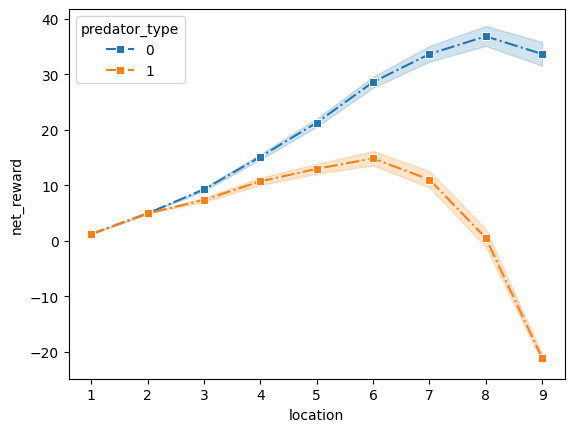

In [24]:
sns.lineplot(data=outcome_df, x='location', y='net_reward', hue='predator_type', marker='s', linestyle='-.')

<Axes: xlabel='location', ylabel='attack_reward_ratio'>

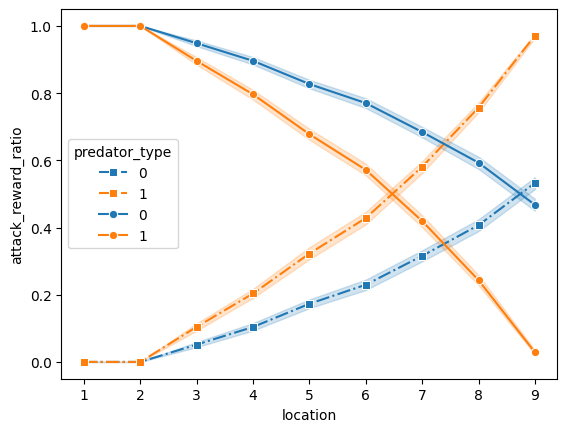

In [35]:
sns.lineplot(data=outcome_df, x='location', y='attack_reward_ratio', hue='predator_type', marker='s', linestyle='-.')

##plot reward_attack_ratio
sns.lineplot(data=outcome_df, x='location', y='reward_attack_ratio', hue='predator_type', marker='o', linestyle='-')

<Axes: xlabel='location', ylabel='reward_attack_ratio'>

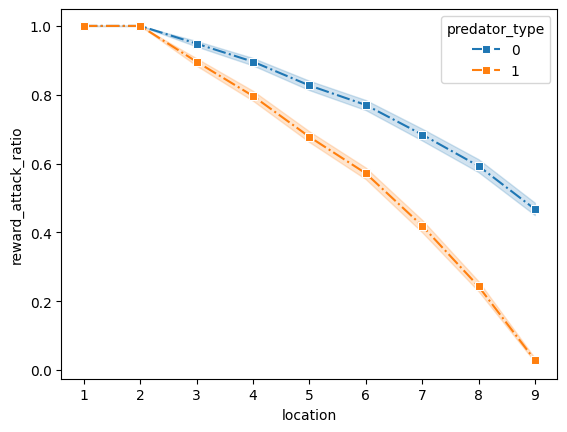

In [30]:
sns.lineplot(data=outcome_df, x='location', y='reward_attack_ratio', hue='predator_type', marker='s', linestyle='-.')